# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
pip install mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import mlflow
import mlflow.sklearn

print('Library berhasil diimport')


Library berhasil diimport


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
print(f'Shape dataset: {df.shape}')
print(f'Jumlah baris : {df.shape[0]:,}')
print(f'Jumlah kolom : {df.shape[1]}')


Shape dataset: (100000, 9)
Jumlah baris : 100,000
Jumlah kolom : 9


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


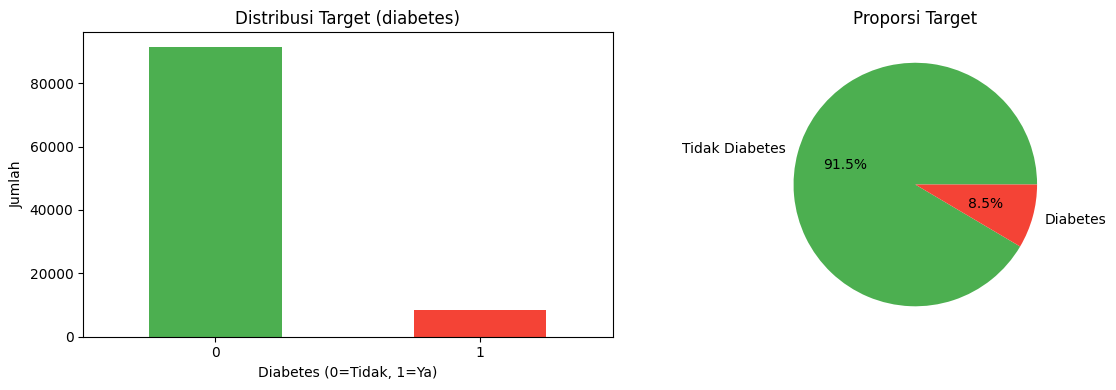

In [5]:
#Type your code here
df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['diabetes'].value_counts().plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'])
axes[0].set_title('Distribusi Target (diabetes)')
axes[0].set_xlabel('Diabetes (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(rotation=0)

df['diabetes'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Tidak Diabetes', 'Diabetes'],
    autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
axes[1].set_title('Proporsi Target')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Shape sebelum drop missing: (100000, 9)
Shape setelah drop missing: (100000, 9)
Missing values tersisa: 0
Shape sebelum drop duplikat: (100000, 9)
Shape setelah drop duplikat: (96146, 9)
Duplikat tersisa: 0
Nilai unik gender: [0 1 2]
Nilai unik smoking_history: [4 0 1 3 2 5]

 Encoding selesai


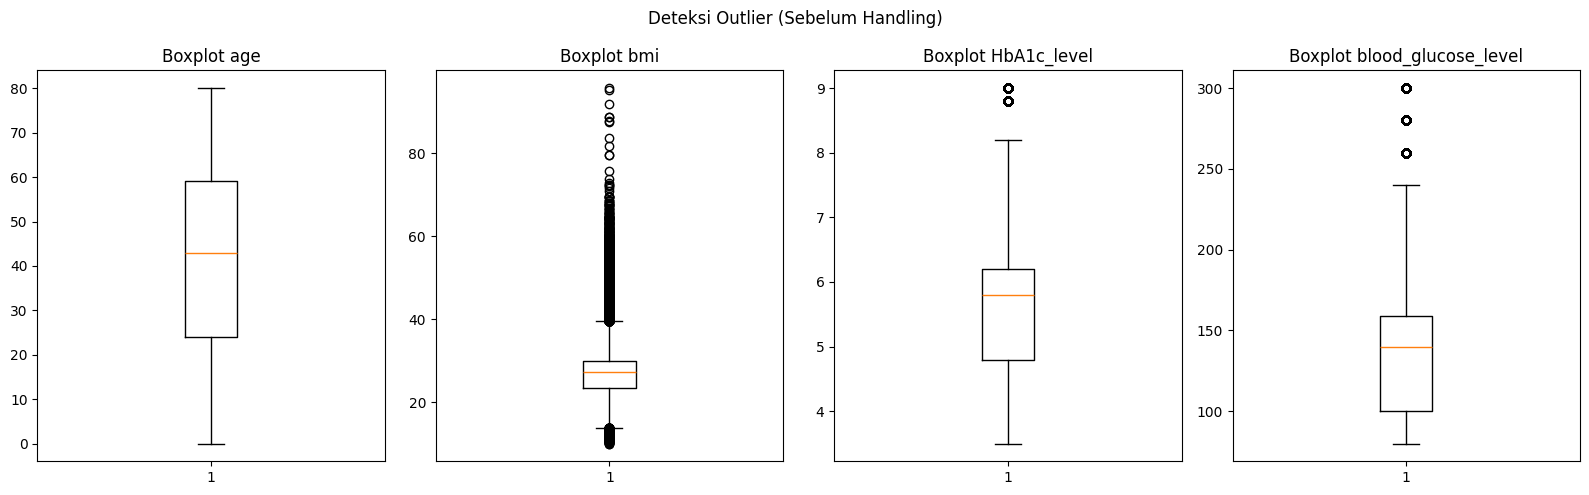

Shape sebelum hapus outlier: (96146, 9)
Shape setelah hapus outlier: (88195, 9)
Distribusi Age Group:
age_group
Dewasa Muda    19440
Dewasa         18704
Paruh Baya     18005
Remaja         17276
Lansia         14770
Name: count, dtype: int64


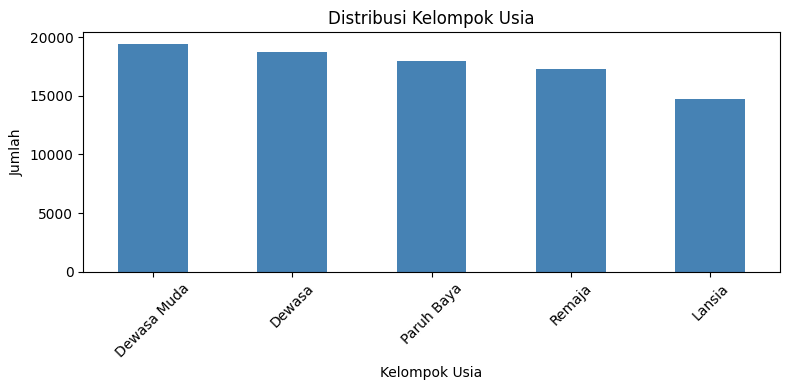

 Standarisasi selesai
         gender       age  hypertension  heart_disease  smoking_history  \
count  88195.00  88195.00      88195.00       88195.00         88195.00   
mean       0.00      0.00          0.00          -0.00             0.00   
std        1.00      1.00          1.00           1.00             1.00   
min       -0.85     -1.81         -0.27          -0.20            -1.16   
25%       -0.85     -0.80         -0.27          -0.20            -1.16   
50%       -0.85      0.04         -0.27          -0.20             0.43   
75%        1.17      0.79         -0.27          -0.20             0.96   
max        3.20      1.72          3.69           5.11             1.48   

            bmi  HbA1c_level  blood_glucose_level  
count  88195.00     88195.00             88195.00  
mean       0.00         0.00                -0.00  
std        1.00         1.00                 1.00  
min       -2.42        -1.97                -1.55  
25%       -0.63        -0.66              

2026/05/30 07:11:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/30 07:11:54 INFO mlflow.store.db.utils: Updating database tables
2026/05/30 07:11:56 INFO mlflow.tracking.fluent: Experiment with name 'diabetes_prediction' does not exist. Creating a new experiment.
2026/05/30 07:12:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/30 07:12:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model trained & logged ke MLflow
Accuracy : 0.9739
ROC-AUC  : 0.9602
=== Classification Report ===
                precision    recall  f1-score   support

Tidak Diabetes       0.97      1.00      0.99     16715
      Diabetes       1.00      0.50      0.67       924

      accuracy                           0.97     17639
     macro avg       0.99      0.75      0.83     17639
  weighted avg       0.97      0.97      0.97     17639



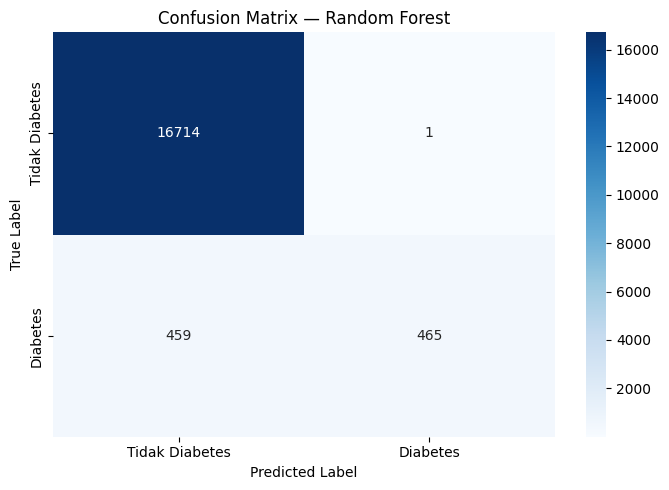

True Negative  (TN): 16714
False Positive (FP): 1
False Negative (FN): 459
True Positive  (TP): 465


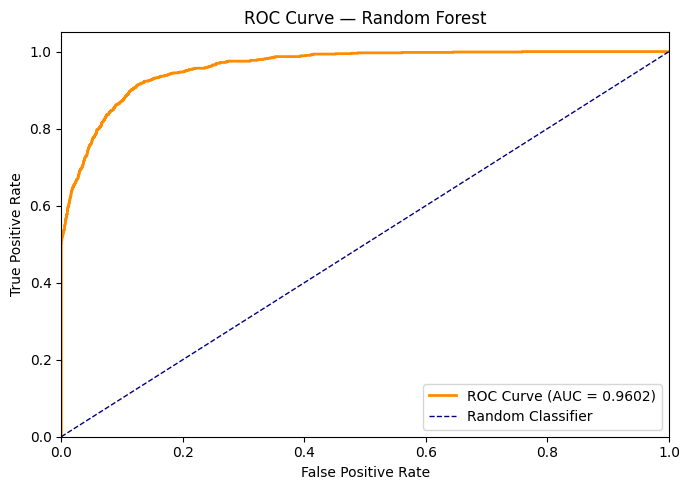

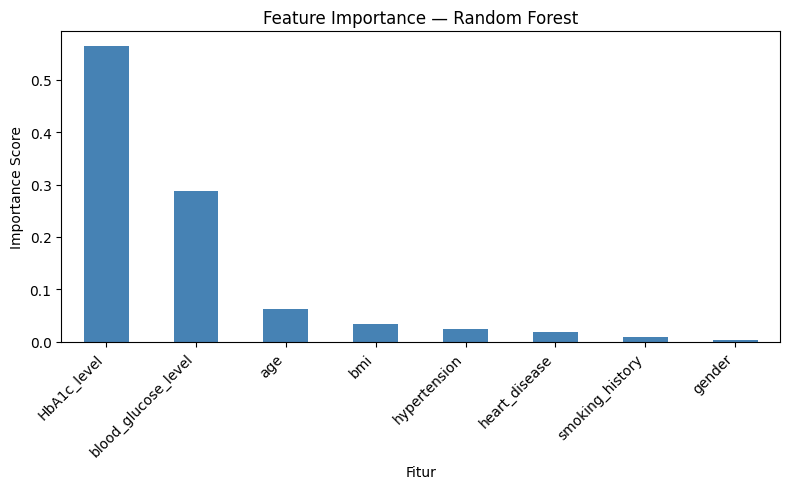

Feature Importance:
HbA1c_level            0.564419
blood_glucose_level    0.287688
age                    0.062532
bmi                    0.032701
hypertension           0.023458
heart_disease          0.018029
smoking_history        0.008488
gender                 0.002684
dtype: float64
Prediksi             : Tidak Diabetes
Probabilitas Diabetes: 0.1210


In [6]:
# Menghapus Missing Values
print(f'Shape sebelum drop missing: {df.shape}')
df = df.dropna()
print(f'Shape setelah drop missing: {df.shape}')
print(f'Missing values tersisa: {df.isnull().sum().sum()}')

# Menghapus Duplikat
print(f'Shape sebelum drop duplikat: {df.shape}')
df = df.drop_duplicates()
print(f'Shape setelah drop duplikat: {df.shape}')
print(f'Duplikat tersisa: {df.duplicated().sum()}')

# Encoding Data Kategorikal
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])

print('Nilai unik gender:', df['gender'].unique())
print('Nilai unik smoking_history:', df['smoking_history'].unique())
print('\n Encoding selesai')

# Deteksi dan Penanganan Outlier (IQR Method)
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(16, 5))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot {col}')
plt.suptitle('Deteksi Outlier (Sebelum Handling)')
plt.tight_layout()
plt.show()

print(f'Shape sebelum hapus outlier: {df.shape}')
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]
print(f'Shape setelah hapus outlier: {df.shape}')

# Binning (Pengelompokan Data) — Age
bins = [0, 18, 35, 50, 65, 100]
labels = ['Remaja', 'Dewasa Muda', 'Dewasa', 'Paruh Baya', 'Lansia']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print('Distribusi Age Group:')
print(df['age_group'].value_counts())

plt.figure(figsize=(8, 4))
df['age_group'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribusi Kelompok Usia')
plt.xlabel('Kelompok Usia')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df = df.drop(columns=['age_group'])

# Normalisasi / Standarisasi Fitur
features = ['gender', 'age', 'hypertension', 'heart_disease',
            'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
target = 'diabetes'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print(' Standarisasi selesai')
print(X_scaled.describe().round(2))

# SPLIT DATA DAN TRAINING MODEL
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')

mlflow.set_experiment('diabetes_prediction')

with mlflow.start_run():
    n_estimators = 100
    max_depth = 10
    random_state = 42

    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_param('max_depth', max_depth)
    mlflow.log_param('random_state', random_state)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('roc_auc', auc)
    mlflow.sklearn.log_model(rf_model, 'model')

    print(f'Model trained & logged ke MLflow')
    print(f'Accuracy : {acc:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')


# EVALUASI MODEL
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Tidak Diabetes', 'Diabetes']))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Diabetes', 'Diabetes'],
            yticklabels=['Tidak Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (TN): {tn}')
print(f'False Positive (FP): {fp}')
print(f'False Negative (FN): {fn}')
print(f'True Positive  (TP): {tp}')


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Fitur')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Feature Importance:')
print(importances)

# PREDIKSI DATA BARU
sample = pd.DataFrame([{
    'gender': 1,
    'age': 45.0,
    'hypertension': 1,
    'heart_disease': 0,
    'smoking_history': 2,
    'bmi': 28.5,
    'HbA1c_level': 6.5,
    'blood_glucose_level': 140
}])

sample_scaled = scaler.transform(sample)
pred = rf_model.predict(sample_scaled)
prob = rf_model.predict_proba(sample_scaled)[0][1]

print(f'Prediksi             : {"Diabetes" if pred[0] == 1 else "Tidak Diabetes"}')
print(f'Probabilitas Diabetes: {prob:.4f}')